# Task 4 — Optimize Portfolio Based on Forecast

Use Modern Portfolio Theory (via `PyPortfolioOpt`) to build the Efficient Frontier for TSLA/BND/SPY, using the Task 3 TSLA forecast as its expected return input.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

from src import data_loader, eda, arima_model, lstm_model, portfolio, backtest


In [2]:
import json
raw = data_loader.fetch_asset_data(cache_dir='../data/raw')
cleaned = data_loader.clean_asset_data(raw)
prices = data_loader.combine_asset_data(cleaned, field='Adj Close')
returns = data_loader.compute_daily_returns(prices)
forecast_summary = json.load(open('../data/processed/task3_forecast_summary.json'))
tsla_annual_return = forecast_summary['annualized_forecast_return_pct'] / 100
tsla_annual_return

2026-07-04 07:47:06,652 [INFO] Loading cached data for TSLA from ../data/raw/TSLA.csv


2026-07-04 07:47:06,694 [INFO] Loading cached data for BND from ../data/raw/BND.csv


2026-07-04 07:47:06,711 [INFO] Loading cached data for SPY from ../data/raw/SPY.csv


2026-07-04 07:47:06,760 [INFO] TSLA: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:47:06,772 [INFO] BND: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:47:06,781 [INFO] SPY: reindexed to 2997 business days, filled 109 missing trading days


0.08112316530823695

## 4.1 Expected returns & covariance matrix

In [3]:
mu = portfolio.build_expected_returns(returns, tsla_annual_return)
cov = portfolio.build_covariance_matrix(returns)
mu

TSLA    0.081123
BND     0.018028
SPY     0.131999
dtype: float64

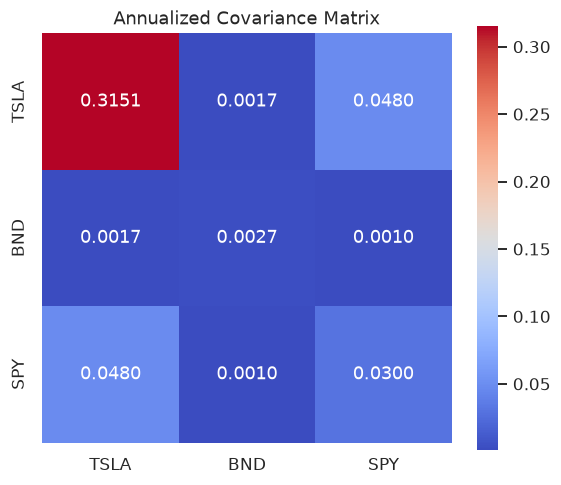

In [4]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cov, annot=True, fmt='.4f', cmap='coolwarm', square=True, ax=ax)
ax.set_title('Annualized Covariance Matrix'); plt.show()

## 4.2 Efficient Frontier

In [5]:
vols, rets, weights_list = portfolio.efficient_frontier_points(mu, cov, n_points=50)
max_sharpe_w, max_sharpe_perf = portfolio.max_sharpe_portfolio(mu, cov)
min_vol_w, min_vol_perf = portfolio.min_volatility_portfolio(mu, cov)
print('Max Sharpe weights:', max_sharpe_w)
print('Min Vol weights:', min_vol_w)

Max Sharpe weights: OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])
Min Vol weights: OrderedDict([('TSLA', 0.0), ('BND', 0.9454), ('SPY', 0.0546)])


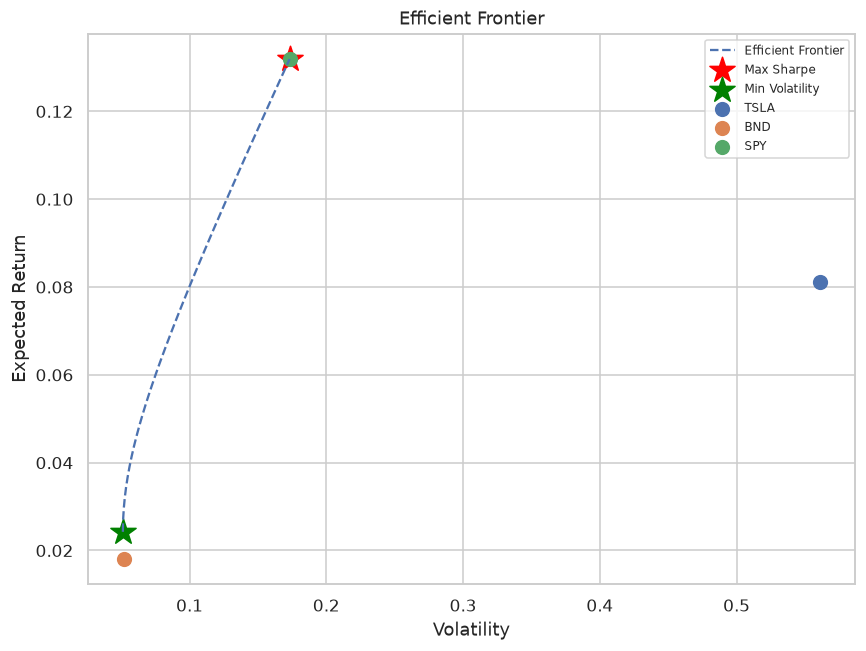

In [6]:
fig, ax = plt.subplots(figsize=(9,6.5))
ax.plot(vols, rets, 'b--', label='Efficient Frontier')
ax.scatter(max_sharpe_perf[1], max_sharpe_perf[0], marker='*', color='red', s=300, label='Max Sharpe')
ax.scatter(min_vol_perf[1], min_vol_perf[0], marker='*', color='green', s=300, label='Min Volatility')
for asset in mu.index:
    idx = list(mu.index).index(asset)
    ax.scatter(np.sqrt(cov.values[idx, idx]), mu[asset], s=80, label=asset)
ax.set_xlabel('Volatility'); ax.set_ylabel('Expected Return'); ax.legend(fontsize=8)
ax.set_title('Efficient Frontier'); plt.show()

## 4.3 Recommendation

The **Maximum Sharpe Ratio portfolio** is recommended as it offers the best risk-adjusted return among all points on the Efficient Frontier. Its weights, expected return, volatility, and Sharpe ratio are printed above and saved to `data/processed/task4_portfolio_recommendation.json`.